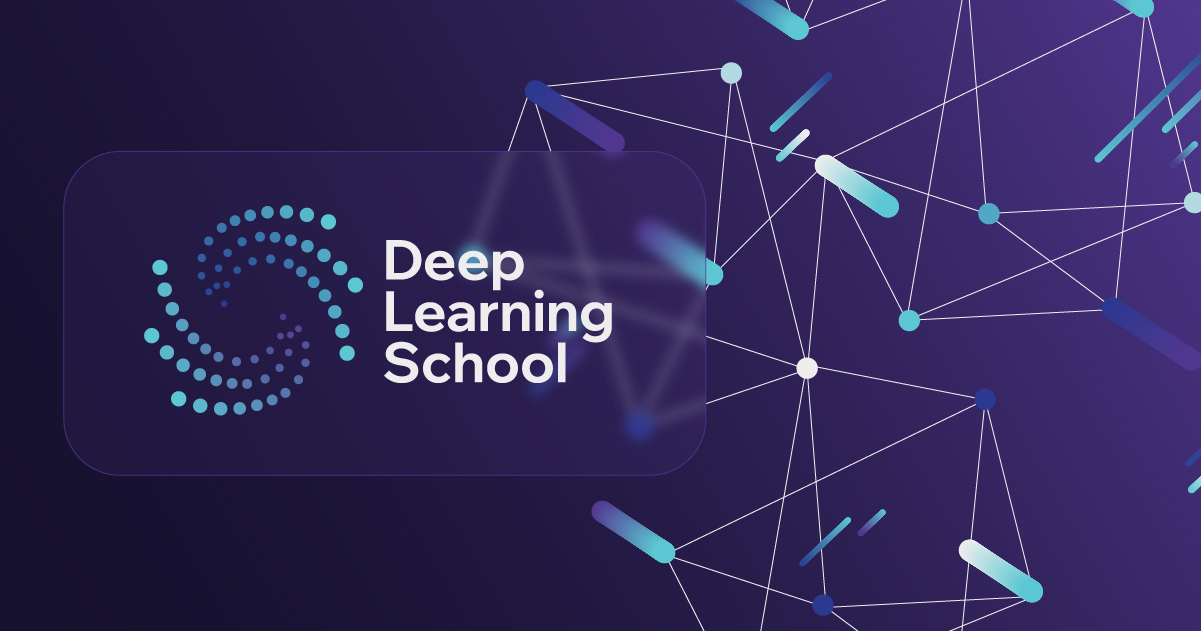


# Домашнее задание "Варианционные автоэнкодеры"

В этом домашнем задании вам предстоит реализовать несколько версий автоэнкодера для работы с изображениями.

Вы научитесь добавлять улыбку на фотографии людей, изменяя их исходное выражение лица с помощью обученной модели. А также, обучите ваш автоэнкодер генерировать изображения рукописных цифр.

# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


Перед тем, как начинать работу с моделями нужно подготовить данные.

In [1]:
import numpy as np
from torch.autograd import Variable
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt

import os
import pandas as pd
import skimage.io
from skimage.transform import resize

import imageio
from PIL import Image
import kagglehub

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

from torchvision import datasets, transforms
from tqdm import tqdm
from sklearn.manifold import TSNE

%matplotlib inline

В этом задании вам предстоить работать с датасетом [LFW (Labeled Faces in the Wild)](https://datasets.activeloop.ai/docs/ml/datasets/lfw-dataset/#:~:text=What%20is%20LFW%20Dataset%3F,commercial%20algorithms%20prior%20to%20release).

In [2]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

Path to dataset files: /kaggle/input/lfw-dataset


In [3]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

Path to dataset files: /kaggle/input/lfw-attributes


In [4]:
DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"

In [5]:
def fetch_dataset(dx=80, dy=80, dimx=64, dimy=64):

    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1,)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns = df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id,' imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)

    df_attrs.columns = df_attrs.columns.str.strip()
    photo_ids.columns = photo_ids.columns.str.strip()

    df = pd.merge(df_attrs,photo_ids,on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    images = df['photo_path'].apply(imageio.imread)\
                                .apply(lambda img:img[dy:-dy, dx:-dx])\
                                .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])) )

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path","person","imagenum"],axis=1)

    return images, attrs

In [6]:
# Обратите внимание, что датасет представляет собой не только картинки, но и атрибуты
# Атрибуты понадобятся в конце этого задания

images, attrs = fetch_dataset()


Разбейте датасет изображений и атрибутов на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

In [7]:
train_images_np, val_images_np, train_attrs, val_attrs = train_test_split(
    images, attrs, train_size=0.9, shuffle=False
)


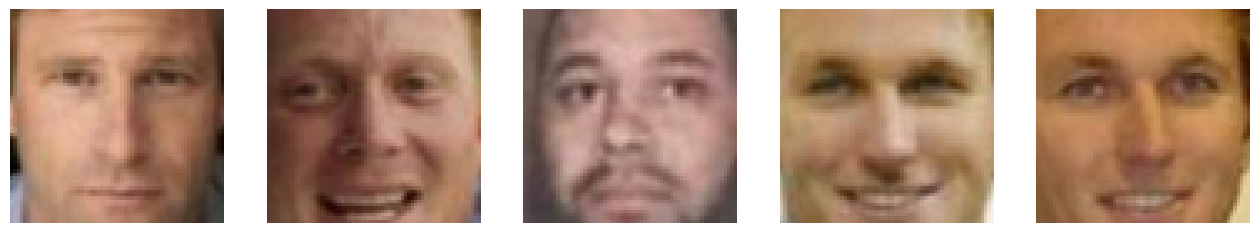

In [8]:
plt.figure(figsize=(16, 8))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(train_images_np[i])
    plt.axis('off')
plt.show()

In [9]:
train_images = torch.from_numpy(train_images_np).permute(0, 3, 1, 2).float() / 255.0
val_images = torch.from_numpy(val_images_np).permute(0, 3, 1, 2).float() / 255.0


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_images = train_images.to(device)
val_images = val_images.to(device)

In [10]:
train_dataset = TensorDataset(train_images)
val_dataset = TensorDataset(val_images)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

In [11]:
for batch in train_loader:
  print(batch[0].size())
  break

torch.Size([64, 3, 64, 64])


## 1.2. Архитектура модели (2 балла)
В этом разделе вы напишите и обучите обычный автоэнкодер.



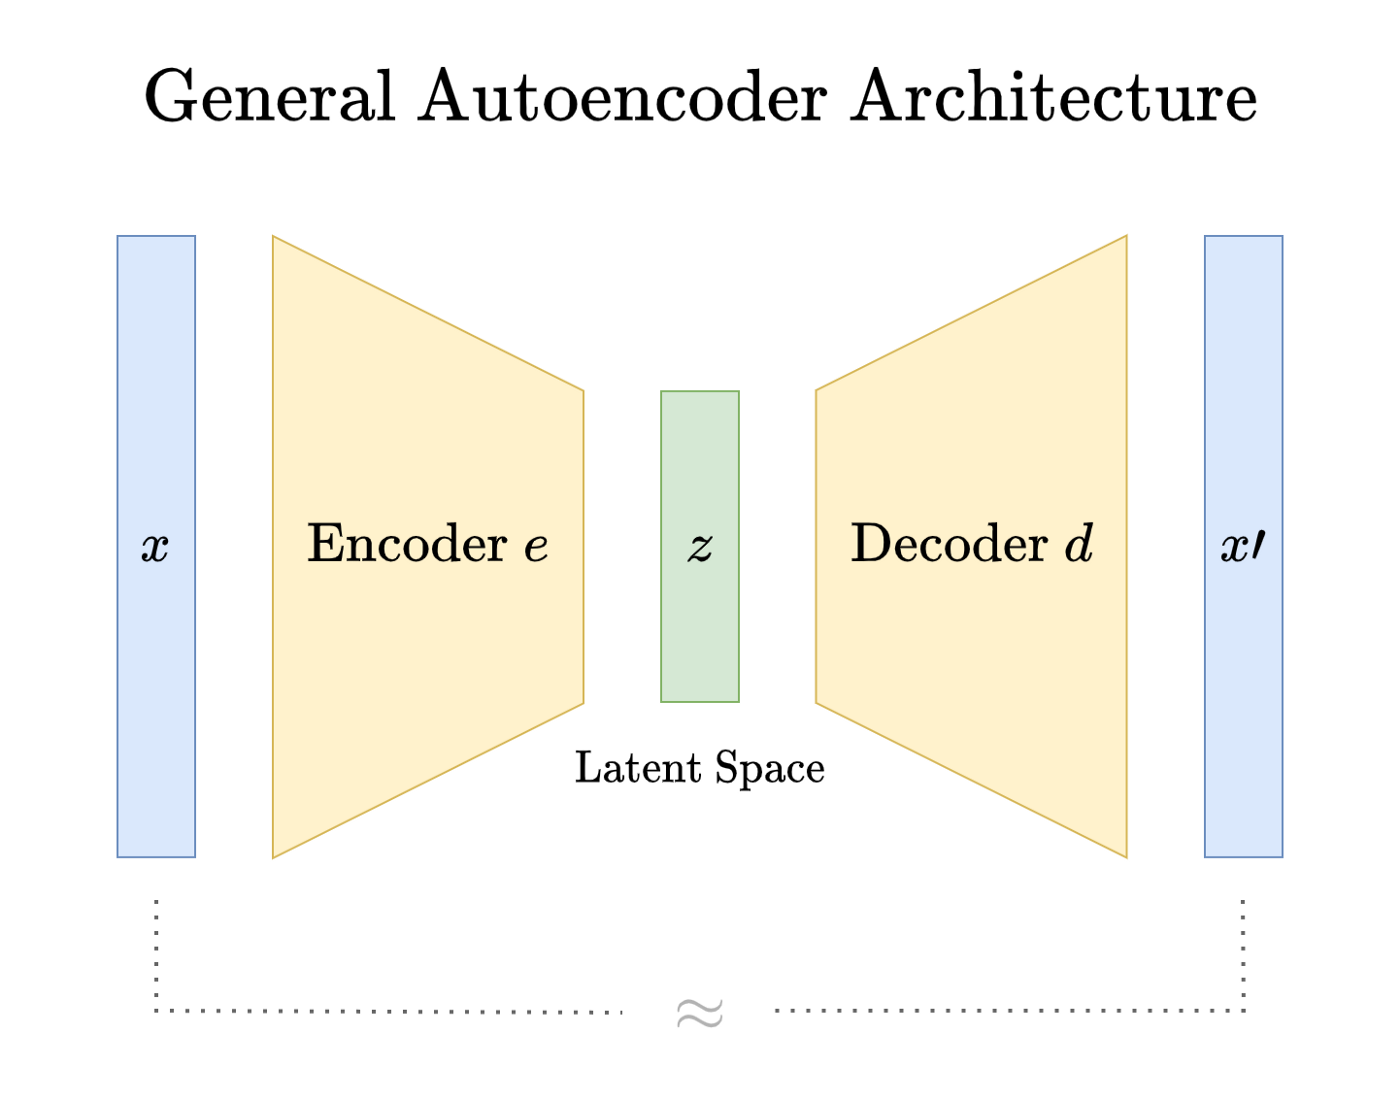

In [12]:
dim_code = 128 # выберите размер латентного вектора

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [13]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(256*4*4, dim_code)
        )

        self.decoder = nn.Sequential(
            nn.Linear(dim_code, 256*4*4),
            nn.Unflatten(1, (256, 4, 4)),
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent_code = self.encoder(x)
        reconstruction = self.decoder(latent_code)
        return reconstruction, latent_code

In [14]:
criterion = nn.MSELoss()

autoencoder = Autoencoder().to(device)

optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)

## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэнкодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

In [15]:
num_epochs = 30

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    autoencoder.train()
    train_loss = 0
    for batch in train_loader:
        images = batch[0].to(device)
        optimizer.zero_grad()
        recon, _ = autoencoder(images)
        loss = criterion(recon, images)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)


    autoencoder.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            images = batch[0].to(device)
            recon, _ = autoencoder(images)
            loss = criterion(recon, images)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1/30 | Train Loss: 0.0232 | Val Loss: 0.0107
Epoch 2/30 | Train Loss: 0.0087 | Val Loss: 0.0073
Epoch 3/30 | Train Loss: 0.0065 | Val Loss: 0.0061
Epoch 4/30 | Train Loss: 0.0055 | Val Loss: 0.0051
Epoch 5/30 | Train Loss: 0.0048 | Val Loss: 0.0045
Epoch 6/30 | Train Loss: 0.0044 | Val Loss: 0.0043
Epoch 7/30 | Train Loss: 0.0040 | Val Loss: 0.0041
Epoch 8/30 | Train Loss: 0.0036 | Val Loss: 0.0037
Epoch 9/30 | Train Loss: 0.0034 | Val Loss: 0.0033
Epoch 10/30 | Train Loss: 0.0031 | Val Loss: 0.0032
Epoch 11/30 | Train Loss: 0.0029 | Val Loss: 0.0030
Epoch 12/30 | Train Loss: 0.0028 | Val Loss: 0.0029
Epoch 13/30 | Train Loss: 0.0027 | Val Loss: 0.0027
Epoch 14/30 | Train Loss: 0.0026 | Val Loss: 0.0028
Epoch 15/30 | Train Loss: 0.0025 | Val Loss: 0.0026
Epoch 16/30 | Train Loss: 0.0024 | Val Loss: 0.0026
Epoch 17/30 | Train Loss: 0.0024 | Val Loss: 0.0025
Epoch 18/30 | Train Loss: 0.0023 | Val Loss: 0.0024
Epoch 19/30 | Train Loss: 0.0023 | Val Loss: 0.0027
Epoch 20/30 | Train L

Давайте посмотрим, как наш тренированный автоэнкодер кодирует и восстанавливает картинки:

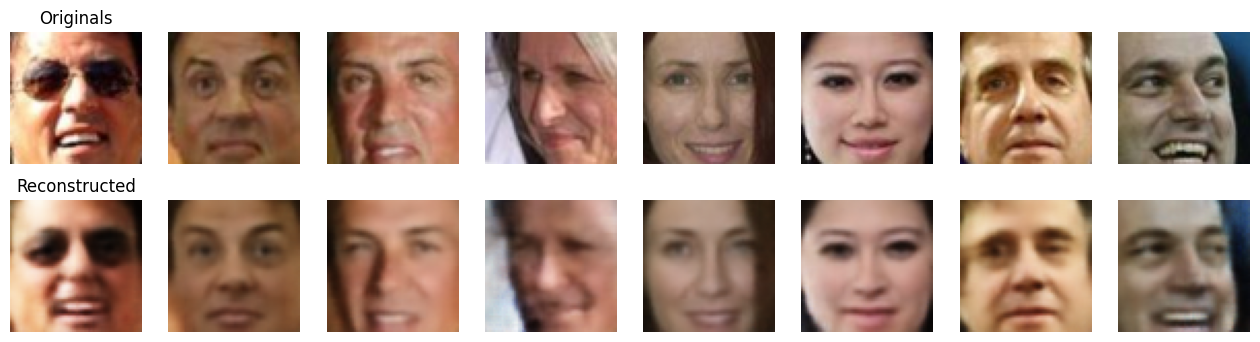

In [16]:
autoencoder.eval()
with torch.no_grad():
    images = next(iter(val_loader))[0].to(device)[:8]
    recon, _ = autoencoder(images)

    images = images.cpu().permute(0, 2, 3, 1).numpy()
    recon = recon.cpu().permute(0, 2, 3, 1).numpy()

    fig, axs = plt.subplots(2, 8, figsize=(16, 4))
    for i in range(8):
        axs[0, i].imshow(images[i])
        axs[0, i].axis('off')
        axs[1, i].imshow(recon[i])
        axs[1, i].axis('off')
    axs[0, 0].set_title('Originals')
    axs[1, 0].set_title('Reconstructed')
    plt.show()


Результат не идеален, но основные фичи энкодеру удается закодировать

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэнкодер и получать реконструкцию, а попробуем создать что-то НОВОЕ!

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__ Если вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

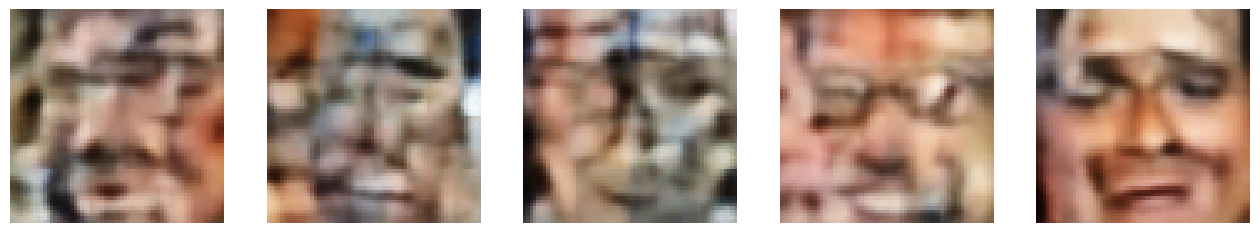

In [17]:
# сгенерируем 25 рандомных векторов размера latent_space
z = torch.randn(25, dim_code).to(device)
with torch.no_grad():
    output = autoencoder.decoder(z)

fig, axes = plt.subplots(1, 5, figsize=(16, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(output[i].detach().cpu().permute(1, 2, 0).numpy())
    ax.axis('off')
plt.show()

Посмотрим, как выглядят латентные векторы картинок из датасета.

In [18]:

latent_list = []

with torch.no_grad():
    for batch in train_loader:
        images = batch[0].to(device)
        _, latent_code = autoencoder(images)
        latent_list.append(latent_code)

latent_tensor = torch.cat(latent_list, dim=0)

mean_z = latent_tensor.mean(dim=0)
std_z = latent_tensor.std(dim=0)


mean_z = mean_z.to(device)
std_z = std_z.to(device)

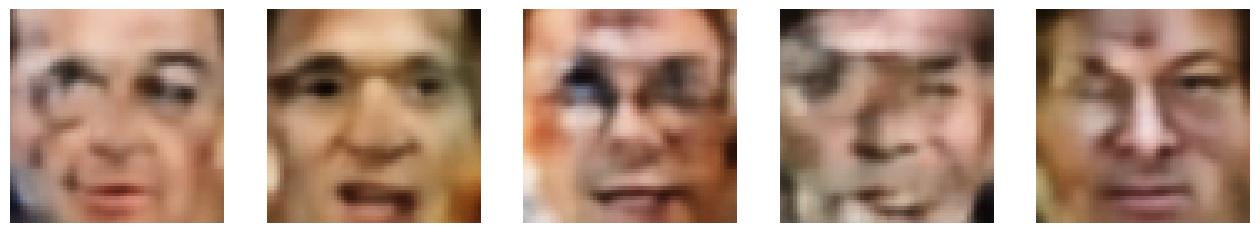

In [19]:
z = torch.randn(5, dim_code).to(device)
z = z * std_z + mean_z
with torch.no_grad():
    output = autoencoder.decoder(z)

fig, axes = plt.subplots(1, 5, figsize=(16, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(output[i].detach().cpu().permute(1, 2, 0).numpy())
    ax.axis('off')
plt.show()

Очевидно, стало лучше

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с атрибутами, скачанный вместе с картинками. В нем указаны имена изображений и присутствубщие атрибуты (улыбки, очки и прочее интересное).

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких.

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей.

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

In [20]:
smile = attrs.index[attrs['Smiling']>0.8].tolist()
smile = smile[:15]
smile

[5, 8, 9, 11, 18, 26, 34, 60, 83, 88, 96, 98, 101, 106, 108]

In [21]:
non_smile = attrs.index[attrs['Smiling']<-0.8].tolist()
non_smile = non_smile[:15]
non_smile

[0, 6, 7, 10, 14, 16, 17, 22, 24, 25, 29, 48, 49, 50, 53]

In [22]:
images, attrs = fetch_dataset()

In [23]:
smiling_images = [images[i] for i in smile]
smiling_images = np.array(smiling_images)

non_smiling_images = [images[i] for i in non_smile]
non_smiling_images = np.array(non_smiling_images)

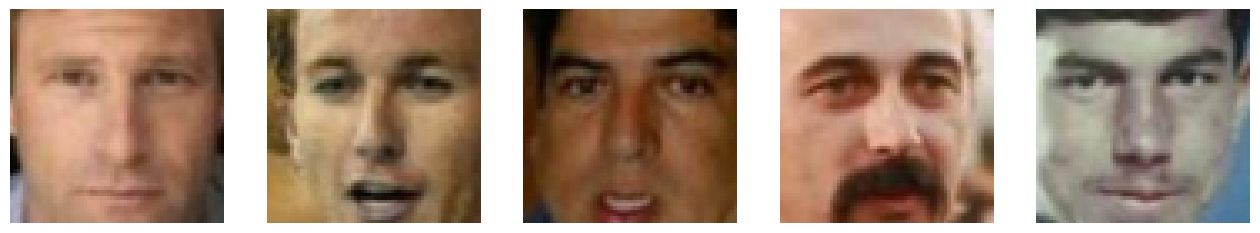

In [24]:
plt.figure(figsize=(16, 8))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(non_smiling_images[i])
    plt.axis('off')
plt.show()

In [25]:
smiling_images = (torch.tensor(smiling_images).permute(0, 3, 1, 2).float() / 255.0).to(device)

In [26]:
non_smiling_images = (torch.tensor(non_smiling_images).permute(0, 3, 1, 2).float() / 255.0).to(device)

In [27]:
smiling_images = TensorDataset(smiling_images)
non_smiling_images = TensorDataset(non_smiling_images)

batch_size = 15

smiling_images = DataLoader(smiling_images, batch_size=batch_size, shuffle=True)
non_smiling_images = DataLoader(non_smiling_images, batch_size=batch_size)

In [28]:
# улыбки
latent_list = []

with torch.no_grad():
    for batch in smiling_images:
        images = batch[0].to(device)
        _, latent_code = autoencoder(images)
        latent_list.append(latent_code)

latent_tensor = torch.cat(latent_list, dim=0)

mean_smile = latent_tensor.mean(dim=0)
std_smile = latent_tensor.std(dim=0)


mean_smile = mean_smile.to(device)
std_smile = std_smile.to(device)

In [29]:
# не улыбки
latent_list = []

with torch.no_grad():
    for batch in non_smiling_images:
        images = batch[0].to(device)
        _, latent_code = autoencoder(images)
        latent_list.append(latent_code)

latent_tensor = torch.cat(latent_list, dim=0)

mean_non_smile = latent_tensor.mean(dim=0)
std_non_smile = latent_tensor.std(dim=0)


mean_non_smile = mean_non_smile.to(device)
std_non_smile = std_non_smile.to(device)

In [30]:
# вектор разности улыбки и не улыбки
diff_smile = mean_smile - mean_non_smile
diff_smile

tensor([-3.5004e-02,  4.9019e-02,  5.9988e-01, -1.2005e+00, -8.5413e-02,
         4.7492e-01,  2.6186e-01,  2.9439e-01,  1.7302e-01,  9.3191e-01,
        -6.2068e-01,  4.2912e-01, -3.5303e-01, -3.7981e-01,  4.2260e-01,
        -1.4994e-03, -5.0933e-01, -2.8725e-01,  8.8234e-01, -6.2505e-01,
        -4.8395e-01,  1.3568e+00, -2.8348e-01, -1.2794e-01,  2.9002e-01,
         4.1230e-01, -2.6455e-01,  7.8518e-01,  9.3925e-02, -6.3308e-01,
         1.6714e-01,  2.5257e-01,  4.3729e-01,  4.1024e-01,  9.1756e-02,
         8.9616e-02, -5.4288e-01,  3.2964e-01, -1.1677e+00, -4.0567e-01,
        -2.0790e-01, -7.4054e-02,  5.4428e-02, -1.3152e+00,  6.2152e-01,
         1.0200e-01, -3.2114e-02,  3.5895e-01, -9.2434e-02,  2.4885e-01,
         2.6475e-01,  3.2623e-01, -1.5140e-01, -1.3717e-01, -7.5414e-02,
         4.9544e-01, -1.6156e-01,  3.5606e-01, -5.9284e-01, -2.6785e-01,
         5.7064e-01, -1.4857e-01,  6.8287e-01,  8.7485e-01, -1.6178e-02,
         4.3717e-01, -7.2503e-01, -6.9329e-03,  6.0

In [31]:
image = next(iter(non_smiling_images))[0].to(device)

with torch.no_grad():
  _, latent_code = autoencoder(images)


new_latent = latent_code + diff_smile

with torch.no_grad():
    output = autoencoder.decoder(new_latent)

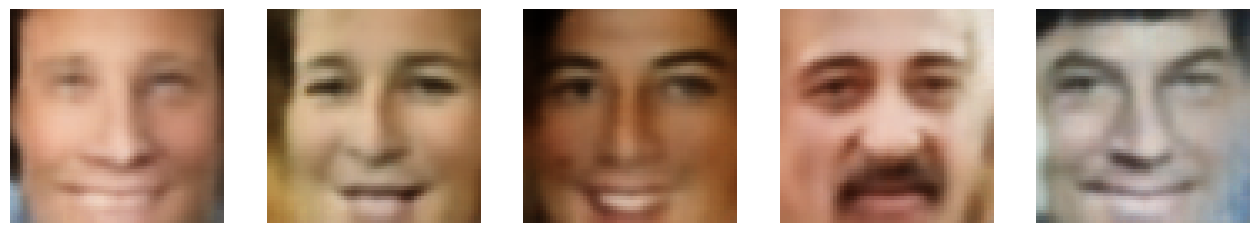

In [32]:
fig, axes = plt.subplots(1, 5, figsize=(16, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(output[i].detach().cpu().permute(1, 2, 0).numpy())
    ax.axis('off')
plt.show()

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... В общем, все, на что хватит фантазии и на что есть атрибуты в `attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [33]:
batch_size = 32
# MNIST Dataset
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.42MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.99MB/s]


## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [34]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [35]:
features = 64

class VAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, features * 2)
        )

        self.decoder_fc = nn.Sequential(
            nn.Linear(features, 128),
            nn.ReLU(),
            nn.Linear(128, 64 * 7 * 7),
            nn.ReLU()
        )

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
        )

    def encode(self, x):
        h = self.encoder(x).view(-1, 2, features)
        mu = h[:, 0, :]
        logsigma = h[:, 1, :]

        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            std = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(std)

            return mu + eps * std
        else:
            return mu

    def decode(self, z):
        h = self.decoder_fc(z)
        h = h.view(-1, 64, 7, 7)
        x_hat = self.decoder_conv(h)
        return x_hat

    def forward(self, x):
        mu, logsigma = self.encode(x)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z)
        reconstruction = torch.sigmoid(reconstruction)

        return mu, logsigma, reconstruction


Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [36]:
def KL_divergence(mu, logsigma):
    """
    часть функции потерь, которая отвечает за "близость" латентных представлений разных людей
    """
    loss = -0.5 * torch.sum(1 + logsigma - mu.pow(2) - logsigma.exp(), dim=1).mean()
    return loss

def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции (как mse в обычном autoencoder)
    """
    loss = nn.BCELoss(reduction='sum')
    return loss(reconstruction, x) / x.size(0)

def loss_vae(x, mu, logsigma, reconstruction):
    return KL_divergence(mu, logsigma) + log_likelihood(x, reconstruction)

И обучим модель:

In [37]:
criterion = loss_vae

autoencoder = VAE().to(device)

optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)

In [38]:
num_epochs = 30

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    autoencoder.train()
    train_loss = 0
    for batch in train_loader:
        images = batch[0].to(device)

        optimizer.zero_grad()
        mu, logsigma, recon = autoencoder(images)
        loss = criterion(images, mu, logsigma, recon)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    autoencoder.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in test_loader:
            images = batch[0].to(device)
            mu, logsigma, recon = autoencoder(images)
            loss = criterion(images, mu, logsigma, recon)
            val_loss += loss.item()

    val_loss /= len(test_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch 1/30 | Train Loss: 4.7598 | Val Loss: 3.5073
Epoch 2/30 | Train Loss: 3.5459 | Val Loss: 3.1805
Epoch 3/30 | Train Loss: 3.3437 | Val Loss: 3.0916
Epoch 4/30 | Train Loss: 3.2659 | Val Loss: 3.0350
Epoch 5/30 | Train Loss: 3.2246 | Val Loss: 2.9922
Epoch 6/30 | Train Loss: 3.1971 | Val Loss: 2.9714
Epoch 7/30 | Train Loss: 3.1740 | Val Loss: 2.9495
Epoch 8/30 | Train Loss: 3.1555 | Val Loss: 2.9701
Epoch 9/30 | Train Loss: 3.1418 | Val Loss: 2.9481
Epoch 10/30 | Train Loss: 3.1301 | Val Loss: 2.9255
Epoch 11/30 | Train Loss: 3.1203 | Val Loss: 2.9201
Epoch 12/30 | Train Loss: 3.1110 | Val Loss: 2.9107
Epoch 13/30 | Train Loss: 3.1022 | Val Loss: 2.9125
Epoch 14/30 | Train Loss: 3.0946 | Val Loss: 2.9278
Epoch 15/30 | Train Loss: 3.0854 | Val Loss: 2.8945
Epoch 16/30 | Train Loss: 3.0763 | Val Loss: 2.8973
Epoch 17/30 | Train Loss: 3.0703 | Val Loss: 2.9176
Epoch 18/30 | Train Loss: 3.0650 | Val Loss: 2.8910
Epoch 19/30 | Train Loss: 3.0601 | Val Loss: 2.8937
Epoch 20/30 | Train L

Давайте посмотрим, как наш тренированный VAE кодирует и восстанавливает картинки:

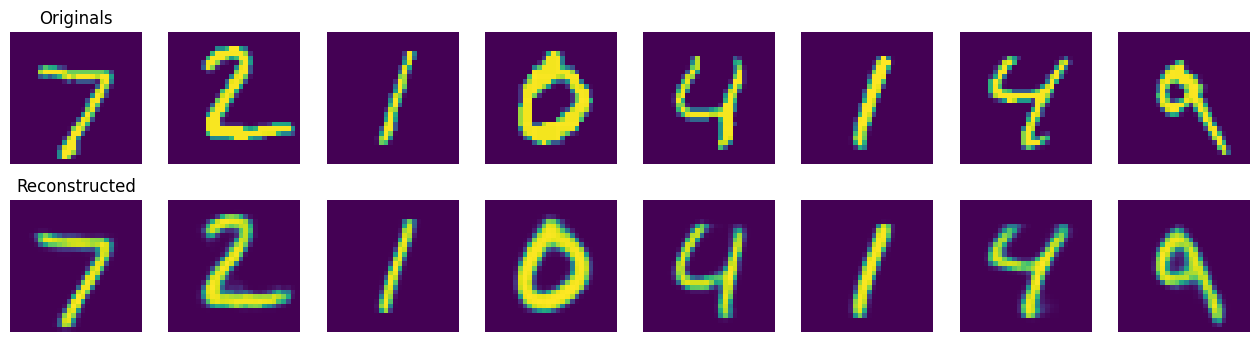

In [39]:
autoencoder.eval()
with torch.no_grad():
    images = next(iter(test_loader))[0].to(device)[0:8]
    mu, logsigma, recon = autoencoder(images)

    images = images.cpu().permute(0, 2, 3, 1).numpy()
    recon = recon.cpu().permute(0, 2, 3, 1).numpy()

    fig, axs = plt.subplots(2, 8, figsize=(16, 4))
    for i in range(8):
        axs[0, i].imshow(images[i])
        axs[0, i].axis('off')
        axs[1, i].imshow(recon[i])
        axs[1, i].axis('off')
    axs[0, 0].set_title('Originals')
    axs[1, 0].set_title('Reconstructed')
    plt.show()

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

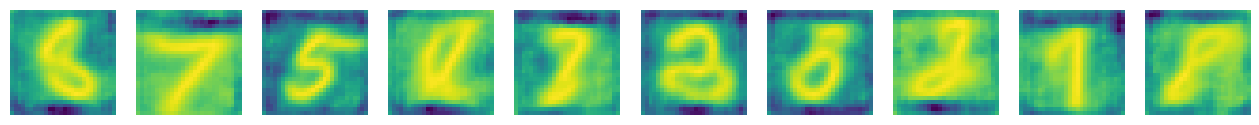

In [40]:
z = torch.from_numpy(np.array([np.random.normal(0, 1, 64) for i in range(128)])).float().to(device)
with torch.no_grad():
    output = autoencoder.decode(z)

fig, axes = plt.subplots(1, 10, figsize=(16, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(output[i].detach().cpu().permute(1, 2, 0).numpy())
    ax.axis('off')
plt.show()

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

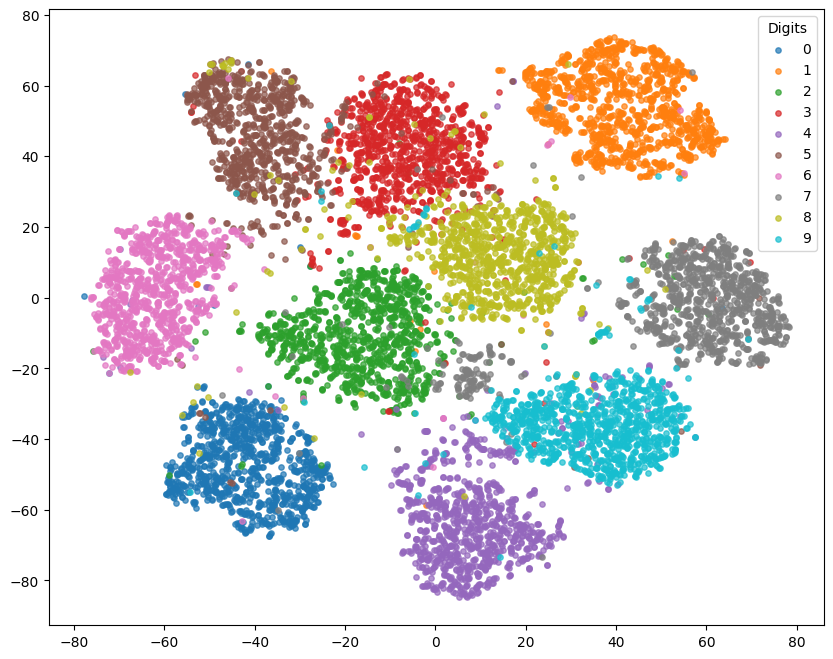

In [41]:
latent_vectors = []
labels = []
with torch.no_grad():
  for x, y in test_loader:
    x = x.to(device)
    mu, _, _ = autoencoder(x)
    latent_vectors.append(mu.cpu().numpy())
    labels.append(y.numpy())

latent_vectors, labels = np.vstack(latent_vectors), np.hstack(labels)

tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_vectors)

plt.figure(figsize=(10, 8))
colors = plt.cm.tab10
for digit in range(10):
    mask = labels == digit
    plt.scatter(latent_2d[mask, 0], latent_2d[mask, 1], c=[colors(digit)], label=str(digit), s=15, alpha=0.7)

plt.legend(title="Digits", loc="best")
plt.show()

Модель достаточно хорошо отделяет разные по написанию цифры. Похожие (например, 3 и 5) находятся близко друг к другу

__Congrats v2.0!__

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [76]:
latent_dim = 64

class CVAE(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.latent_dim = latent_dim

        # Энкодер
        self.encoder = nn.Sequential(
            nn.Conv2d(1 + 10, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim * 2)
        )


        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim + 10, 128),
            nn.ReLU(),
            nn.Linear(128, 64 * 7 * 7),
            nn.ReLU()
        )

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x, class_onehot):

        class_onehot = class_onehot.view(-1, 10, 1, 1).expand(-1, 10, x.shape[2], x.shape[3])
        x = torch.cat([x, class_onehot], dim=1)
        h = self.encoder(x)
        mu, logvar = h.chunk(2, dim=1)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            return mu

    def decode(self, z, class_onehot):

        z = torch.cat([z, class_onehot], dim=1)
        h = self.decoder_fc(z)
        h = h.view(-1, 64, 7, 7)
        return self.decoder_conv(h)

    def forward(self, x, class_onehot):
        mu, logvar = self.encode(x, class_onehot)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, class_onehot), mu, logvar

In [70]:
criterion = loss_vae

autoencoder = CVAE().to(device)

optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)

In [75]:
num_epochs = 30
class_num = 10

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    autoencoder.train()
    train_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels_onehot = F.one_hot(labels, num_classes=10).float().to(device)

        optimizer.zero_grad()
        recon, mu, logvar = autoencoder(images, labels_onehot)
        loss = criterion(images, mu, logvar, recon)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()


    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)


    autoencoder.eval()
    val_loss = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels_onehot = F.one_hot(labels, num_classes=10).float().to(device)

            recon, mu, logvar = autoencoder(images, labels_onehot)
            loss = criterion(images, mu, logvar, recon)
            val_loss += loss.item()

    val_loss /= len(test_loader.dataset)
    val_losses.append(val_loss)

    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

Epoch 1/30, Train Loss: 3.2100, Val Loss: 2.9478
Epoch 2/30, Train Loss: 3.1412, Val Loss: 2.9101
Epoch 3/30, Train Loss: 3.0906, Val Loss: 2.8641
Epoch 4/30, Train Loss: 3.0534, Val Loss: 2.8543
Epoch 5/30, Train Loss: 3.0291, Val Loss: 2.8540
Epoch 6/30, Train Loss: 3.0109, Val Loss: 2.8461
Epoch 7/30, Train Loss: 2.9965, Val Loss: 2.7968
Epoch 8/30, Train Loss: 2.9834, Val Loss: 2.8203
Epoch 9/30, Train Loss: 2.9738, Val Loss: 2.7820
Epoch 10/30, Train Loss: 2.9639, Val Loss: 2.7752
Epoch 11/30, Train Loss: 2.9559, Val Loss: 2.7725
Epoch 12/30, Train Loss: 2.9472, Val Loss: 2.7763
Epoch 13/30, Train Loss: 2.9387, Val Loss: 2.7729
Epoch 14/30, Train Loss: 2.9326, Val Loss: 2.7477
Epoch 15/30, Train Loss: 2.9255, Val Loss: 2.7452
Epoch 16/30, Train Loss: 2.9200, Val Loss: 2.7626
Epoch 17/30, Train Loss: 2.9153, Val Loss: 2.7464
Epoch 18/30, Train Loss: 2.9114, Val Loss: 2.7417
Epoch 19/30, Train Loss: 2.9074, Val Loss: 2.7498
Epoch 20/30, Train Loss: 2.9033, Val Loss: 2.7450
Epoch 21/

### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

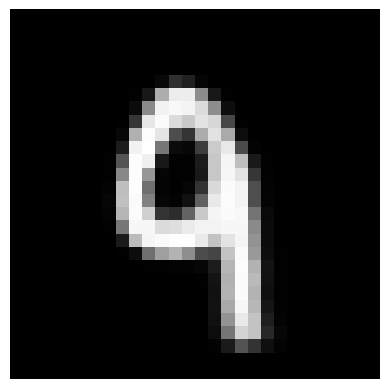

In [90]:
labels = torch.tensor([9]).to(device)
sample_onehot = F.one_hot(labels, num_classes=10).float()

sample_z = torch.randn(1, 64).to(device)
sample_image = autoencoder.decode(sample_z, sample_onehot)

plt.imshow(sample_image.view(28, 28).detach().cpu().numpy(), cmap='gray')
plt.axis('off')
plt.show()

Splendid! Вы великолепны!


### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

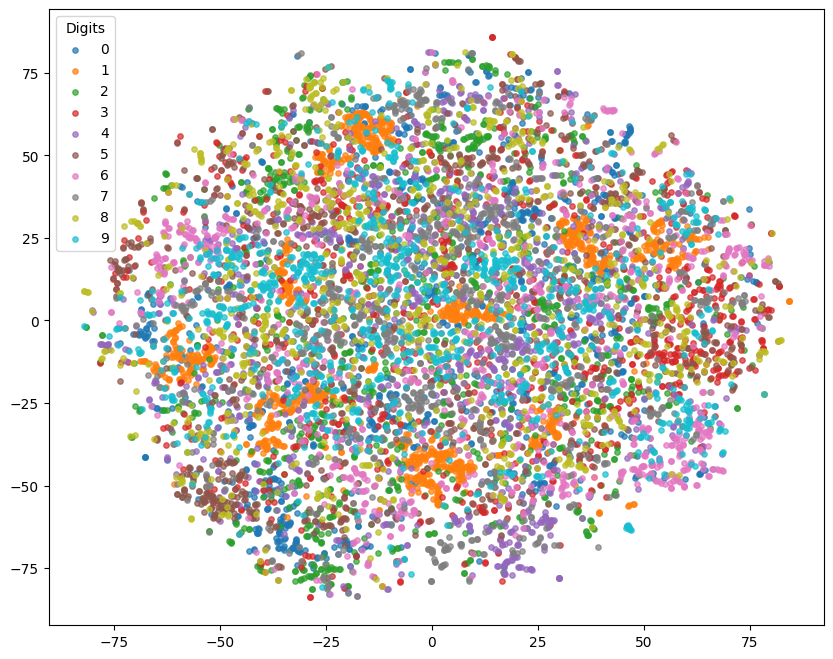

In [98]:
latent_vectors = []
true_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels_onehot = F.one_hot(labels, num_classes=10).float().to(device)
        mu, _ = autoencoder.encode(images, labels_onehot)

        latent_vectors.append(mu.cpu().numpy())
        true_labels.append(labels.numpy())

latent_vectors = np.vstack(latent_vectors)
true_labels = np.concatenate(true_labels)

tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_vectors)

plt.figure(figsize=(10, 8))
colors = plt.cm.tab10
for digit in range(10):
    mask = true_labels == digit
    plt.scatter(latent_2d[mask, 0], latent_2d[mask, 1],
                color=colors(digit),
                label=str(digit),
                s=15,
                alpha=0.7)

plt.legend(title="Digits", loc="best")
plt.show()

Модель значительно хуже отделяет разные классы друг от друга (можно сказать, не отделяет вовсе)